# Codes

In [257]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

GROUP = "TRACE_DATA/DEFAULT"

# Helper Functions

In [356]:
def inspect_dataset(path):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        data_shape = g["data_array"].shape

        shot_ids = g["SHOTID"][:].ravel()
        unique_shots, counts = np.unique(
            shot_ids,
            return_counts=True
        )

        labels = g["SPARE1"][:].ravel()
        labeled = labels > 0

        sample_rate = g["SAMP_RATE"][:].ravel()

        print("=" * 65)
        print("DATASET")
        print("=" * 65)
        print(f"Traces             : {data_shape[0]:,}")
        print(f"Samples per trace  : {data_shape[1]:,}")
        print(f"Data type          : {g['data_array'].dtype}")
        print(f"Unique SHOTIDs     : {len(unique_shots):,}")
        print(f"Traces per shot    : {counts.min()} - {counts.max()}")
        print(f"Average per shot   : {counts.mean():.1f}")
        print(f"Median per shot    : {np.median(counts):.1f}")
        print(f"Labeled traces     : {labeled.sum():,}")
        print(f"Unlabeled traces   : {(~labeled).sum():,}")
        print(f"Labeled percentage : {100 * labeled.mean():.2f}%")
        print(f"SAMP_RATE values   : {np.unique(sample_rate)}")

        if labeled.any():
            print(
                f"First-break range : "
                f"{labels[labeled].min():.1f} - "
                f"{labels[labeled].max():.1f} ms"
            )

        print("\nFirst 10 SHOTIDs:")
        for shot, count in zip(unique_shots[:10], counts[:10]):
            print(f"  {shot}: {count} traces")

        print("\nMetadata:")
        for name in [
            "INLINE", "CROSSLINE", "CDP", "OFFSET",
            "SOURCE_X", "SOURCE_Y",
            "REC_X", "REC_Y",
            "SHOTID", "CHANNEL",
            "SAMP_NUM", "SAMP_RATE", "SPARE1"
        ]:
            print(
                f"  {name:15} "
                f"shape={g[name].shape}, "
                f"dtype={g[name].dtype}"
            )

        return unique_shots, counts

In [357]:
def inspect_one_trace(path, i):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        source_x = g["SOURCE_X"][i].item()
        source_y = g["SOURCE_Y"][i].item()
        rec_x = g["REC_X"][i].item()
        rec_y = g["REC_Y"][i].item()

        offset = g["OFFSET"][i].item()
        shot_id = g["SHOTID"][i].item()
        inline = g["INLINE"][i].item()
        crossline = g["CROSSLINE"][i].item()
        cdp = g["CDP"][i].item()
        first_break = g["SPARE1"][i].item()
        samp_rate = g["SAMP_RATE"][i].item()

        distance = np.sqrt(
            (source_x - rec_x) ** 2 +
            (source_y - rec_y) ** 2
        )

        print("=" * 50)
        print(f"TRACE {i}")
        print("=" * 50)
        print(f"SHOTID       : {shot_id}")
        print(f"INLINE       : {inline}")
        print(f"CROSSLINE    : {crossline}")
        print(f"CDP          : {cdp}")
        print(f"OFFSET       : {offset}")
        print(f"CALC DISTANCE: {distance:.2f}")
        print(f"DIFFERENCE   : {abs(distance - offset):.2f}")
        print(f"SOURCE       : ({source_x}, {source_y})")
        print(f"RECEIVER     : ({rec_x}, {rec_y})")
        print(f"FIRST BREAK  : {first_break} ms")
        print(f"SAMP_RATE    : {samp_rate}")

In [358]:
def plot_one_trace(path, i, n=800):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        signal = g["data_array"][i]
        fb_ms = g["SPARE1"][i].item()
        dt_ms = g["SAMP_RATE"][i].item() / 1000

        n = min(n, len(signal))

        samples = np.arange(n)
        time_ms = samples * dt_ms

    fig, axes = plt.subplots(2, 1, figsize=(11, 7))

    axes[0].plot(samples, signal[:n])
    axes[0].set_xlabel("Sample number")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Trace {i} — Sample domain")

    axes[1].plot(time_ms, signal[:n])

    if fb_ms > 0 and fb_ms <= time_ms[-1]:
        axes[1].axvline(
            fb_ms,
            color="black",
            linewidth=2,
            label=f"First break = {fb_ms:.1f} ms"
        )
        axes[1].legend()

    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title(f"Trace {i} — Time domain")

    plt.tight_layout()
    plt.show()

    print(
        f"Trace {i}: {len(signal)} samples, "
        f"dt = {dt_ms} ms, "
        f"first break = {fb_ms} ms"
    )

In [359]:
def load_metadata(path):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        raw = {
            "shot_id": g["SHOTID"][:].ravel(),
            "source_x": g["SOURCE_X"][:].ravel().astype(float),
            "source_y": g["SOURCE_Y"][:].ravel().astype(float),
            "rec_x": g["REC_X"][:].ravel().astype(float),
            "rec_y": g["REC_Y"][:].ravel().astype(float),
            "offset": g["OFFSET"][:].ravel().astype(float),
            "fb_ms": g["SPARE1"][:].ravel().astype(float),
            "samp_rate": g["SAMP_RATE"][:].ravel().astype(float)
        }

    raw["distance"] = np.sqrt(
        (raw["rec_x"] - raw["source_x"]) ** 2 +
        (raw["rec_y"] - raw["source_y"]) ** 2
    )

    return raw

In [360]:
def plot_raw_section(path, start=0, num_traces=500):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        total = g["data_array"].shape[0]
        end = min(start + num_traces, total)

        data = g["data_array"][start:end]
        labels = g["SPARE1"][start:end].ravel()
        dt_ms = g["SAMP_RATE"][start].item() / 1000

    n_traces, n_samples = data.shape

    time_ms = np.arange(n_samples) * dt_ms
    trace_numbers = np.arange(n_traces)

    valid = labels > 0

    plt.figure(figsize=(14, 8))

    plt.imshow(
        data.T,
        aspect="auto",
        cmap="seismic",
        extent=[
            0,
            n_traces - 1,
            time_ms[-1],
            time_ms[0]
        ]
    )

    plt.plot(
        trace_numbers[valid],
        labels[valid],
        color="black",
        linewidth=1.5
    )

    plt.xlabel("Trace number in original HDF5 order")
    plt.ylabel("Time (ms)")
    plt.title(
        f"Raw seismic section — traces {start}–{end - 1}\n"
        "No SHOTID grouping"
    )

    plt.colorbar(label="Amplitude")

    plt.tight_layout()
    plt.show()

In [361]:
def get_shot(path, shot_id, order_by=None):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        shot_ids = g["SHOTID"][:].ravel()
        indices = np.where(shot_ids == shot_id)[0]

        if len(indices) == 0:
            raise ValueError(f"SHOTID {shot_id} was not found.")

        source_x = g["SOURCE_X"][indices].ravel().astype(float)
        source_y = g["SOURCE_Y"][indices].ravel().astype(float)
        rec_x = g["REC_X"][indices].ravel().astype(float)
        rec_y = g["REC_Y"][indices].ravel().astype(float)

        distance = np.sqrt(
            (rec_x - source_x) ** 2 +
            (rec_y - source_y) ** 2
        )

        offset = g["OFFSET"][indices].ravel().astype(float)
        fb_ms = g["SPARE1"][indices].ravel().astype(float)

        dt_ms = g["SAMP_RATE"][indices[0]].item() / 1000

        if order_by == "distance":
            order = np.argsort(distance)
        elif order_by == "offset":
            order = np.argsort(offset)
        else:
            order = np.arange(len(indices))

        # Determine which original HDF5 rows need to be read.
        requested_indices = indices[order]

        # h5py requires fancy indices to be increasing.
        read_order = np.argsort(requested_indices)
        sorted_indices = requested_indices[read_order]

        # Read traces in increasing HDF5-index order.
        traces_sorted = g["data_array"][sorted_indices]

        # Put them back into the requested order.
        traces = traces_sorted[np.argsort(read_order)]

        return {
            "shot_id": shot_id,
            "indices": requested_indices,
            "traces": traces,
            "distance": distance[order],
            "offset": offset[order],
            "fb_ms": fb_ms[order],
            "dt_ms": dt_ms
        }

In [362]:
def plot_shot(gather, title, x_axis="trace"):
    traces = gather["traces"]
    labels = gather["fb_ms"]

    n_traces, n_samples = traces.shape

    time_ms = np.arange(n_samples) * gather["dt_ms"]

    if x_axis == "trace":
        x = np.arange(n_traces)
        xlabel = "Trace number"

    elif x_axis == "distance":
        x = gather["distance"]
        xlabel = "Calculated source–receiver distance"

    elif x_axis == "offset":
        x = gather["offset"]
        xlabel = "Stored OFFSET"

    else:
        raise ValueError(
            "x_axis must be 'trace', 'distance', or 'offset'"
        )

    valid = labels > 0

    plt.figure(figsize=(14, 8))

    plt.imshow(
        traces.T,
        aspect="auto",
        cmap="seismic",
        extent=[
            x[0],
            x[-1],
            time_ms[-1],
            time_ms[0]
        ]
    )

    plt.plot(
        x[valid],
        labels[valid],
        color="black",
        linewidth=2
    )

    plt.xlabel(xlabel)
    plt.ylabel("Time (ms)")
    plt.title(title)

    plt.colorbar(label="Amplitude")

    plt.tight_layout()
    plt.show()

In [363]:
def compare_distance_offset(raw):
    difference = np.abs(
        raw["distance"] - raw["offset"]
    )

    print("=" * 55)
    print("CALCULATED DISTANCE vs STORED OFFSET")
    print("=" * 55)

    print(f"Mean difference    : {difference.mean():.3f}")
    print(f"Median difference  : {np.median(difference):.3f}")
    print(f"Maximum difference : {difference.max():.3f}")
    print(f"90th percentile    : {np.percentile(difference, 90):.3f}")

    print("\nExamples:")

    for i in range(min(10, len(difference))):
        print(
            f"Trace {i}: "
            f"distance={raw['distance'][i]:.2f}, "
            f"OFFSET={raw['offset'][i]:.2f}, "
            f"diff={difference[i]:.2f}"
        )

In [364]:
def select_test_shots(path, n=5):
    with h5py.File(path, "r") as f:
        shot_ids = f[GROUP]["SHOTID"][:].ravel()

    unique_shots, counts = np.unique(
        shot_ids,
        return_counts=True
    )

    order = np.argsort(counts)[::-1]

    selected = unique_shots[
        order[:n]
    ]

    print("Selected shots:")
    for shot in selected:
        count = counts[
            np.where(unique_shots == shot)[0][0]
        ]
        print(f"  SHOTID {shot}: {count} traces")

    return selected

# Data Inspection and Visualization

## Brunswick

In [365]:
path = r"data\Brunswick_orig_1500ms_V2.hdf5"

inspect_dataset(path)

DATASET
Traces             : 4,496,540
Samples per trace  : 751
Data type          : float32
Unique SHOTIDs     : 1,541
Traces per shot    : 2135 - 3355
Average per shot   : 2917.9
Median per shot    : 2975.0
Labeled traces     : 3,733,221
Unlabeled traces   : 763,319
Labeled percentage : 83.02%
SAMP_RATE values   : [2000]
First-break range : 4.0 - 1358.0 ms

First 10 SHOTIDs:
  1: 2582 traces
  2: 2582 traces
  3: 2582 traces
  4: 2582 traces
  5: 2582 traces
  6: 2582 traces
  7: 2582 traces
  8: 2582 traces
  9: 2582 traces
  10: 2582 traces

Metadata:
  INLINE          shape=(4496540, 1), dtype=uint32
  CROSSLINE       shape=(4496540, 1), dtype=uint32
  CDP             shape=(4496540, 1), dtype=uint32
  OFFSET          shape=(4496540, 1), dtype=int32
  SOURCE_X        shape=(4496540, 1), dtype=int32
  SOURCE_Y        shape=(4496540, 1), dtype=int32
  REC_X           shape=(4496540, 1), dtype=int32
  REC_Y           shape=(4496540, 1), dtype=int32
  SHOTID          shape=(4496540, 1

(array([   1,    2,    3, ..., 1815, 1816, 1817],
       shape=(1541,), dtype=uint32),
 array([2582, 2582, 2582, ..., 2362, 2362, 2362], shape=(1541,)))

TRACE 5
SHOTID       : 1
INLINE       : 1079
CROSSLINE    : 1506
CDP          : 10791506
OFFSET       : 34820
CALC DISTANCE: 34827.38
DIFFERENCE   : 7.38
SOURCE       : (2876700, 52530740)
RECEIVER     : (2875600, 52565550)
FIRST BREAK  : 638 ms
SAMP_RATE    : 2000


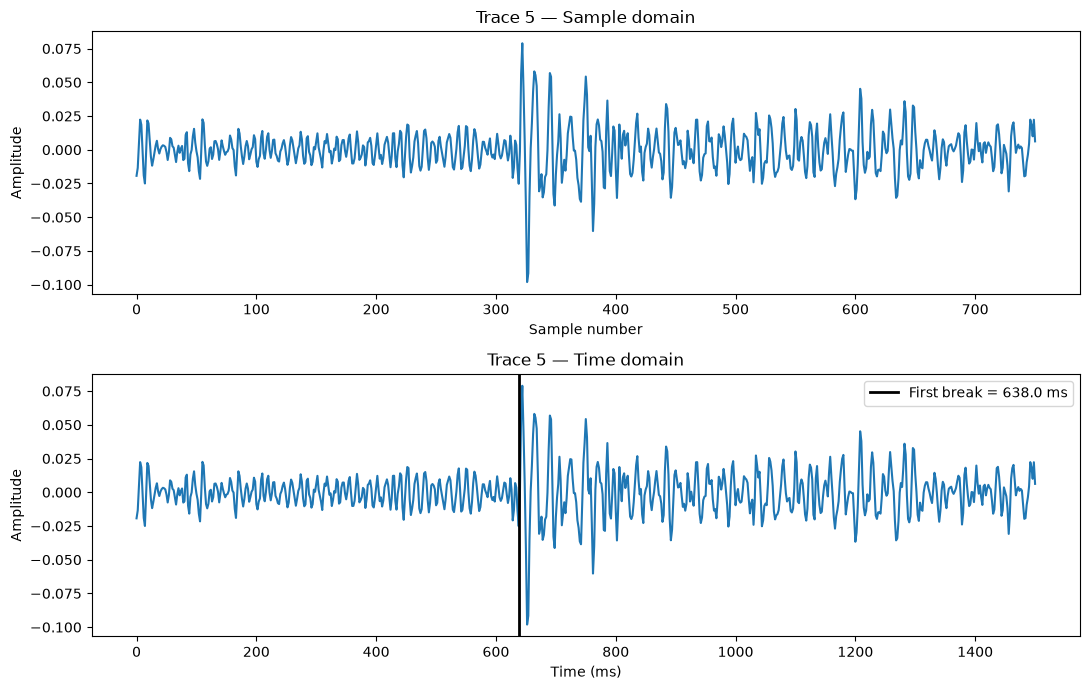

Trace 5: 751 samples, dt = 2.0 ms, first break = 638 ms


In [366]:
inspect_one_trace(path, 5)
plot_one_trace(path, 5)

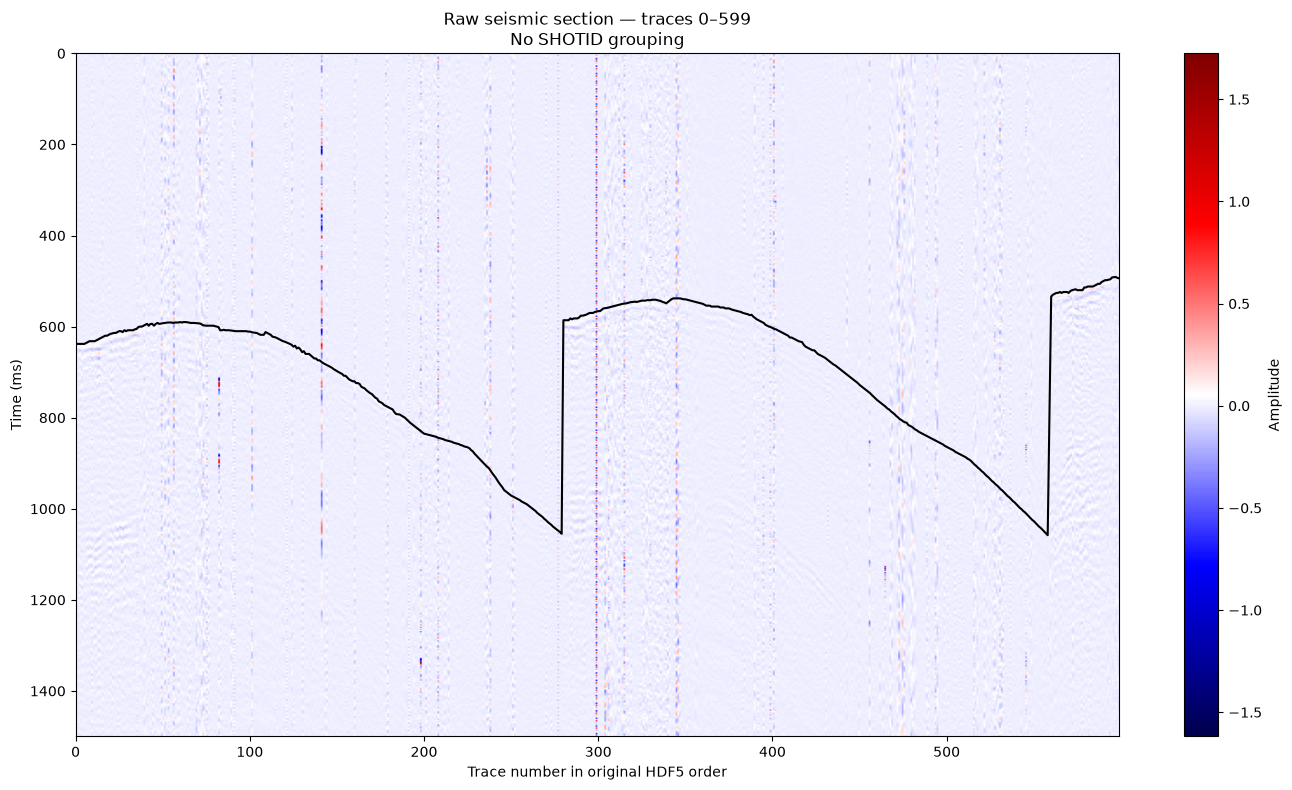

In [367]:
plot_raw_section(
    path,
    start=0,
    num_traces=600
)

In [368]:
raw = load_metadata(path)

compare_distance_offset(raw)

CALCULATED DISTANCE vs STORED OFFSET
Mean difference    : 4.063
Median difference  : 3.506
Maximum difference : 18.775
90th percentile    : 8.367

Examples:
Trace 0: distance=35280.14, OFFSET=35270.00, diff=10.14
Trace 1: distance=35181.37, OFFSET=35180.00, diff=1.37
Trace 2: distance=35093.56, OFFSET=35090.00, diff=3.56
Trace 3: distance=35007.00, OFFSET=35000.00, diff=7.00
Trace 4: distance=34911.60, OFFSET=34910.00, diff=1.60
Trace 5: distance=34827.38, OFFSET=34820.00, diff=7.38
Trace 6: distance=34744.33, OFFSET=34730.00, diff=14.33
Trace 7: distance=34652.48, OFFSET=34650.00, diff=2.48
Trace 8: distance=34571.82, OFFSET=34570.00, diff=1.82
Trace 9: distance=34482.39, OFFSET=34480.00, diff=2.39


In [369]:
test_shots = select_test_shots(path, n=3)
shot_id = test_shots[0]

Selected shots:
  SHOTID 973: 3355 traces
  SHOTID 972: 3355 traces
  SHOTID 971: 3355 traces


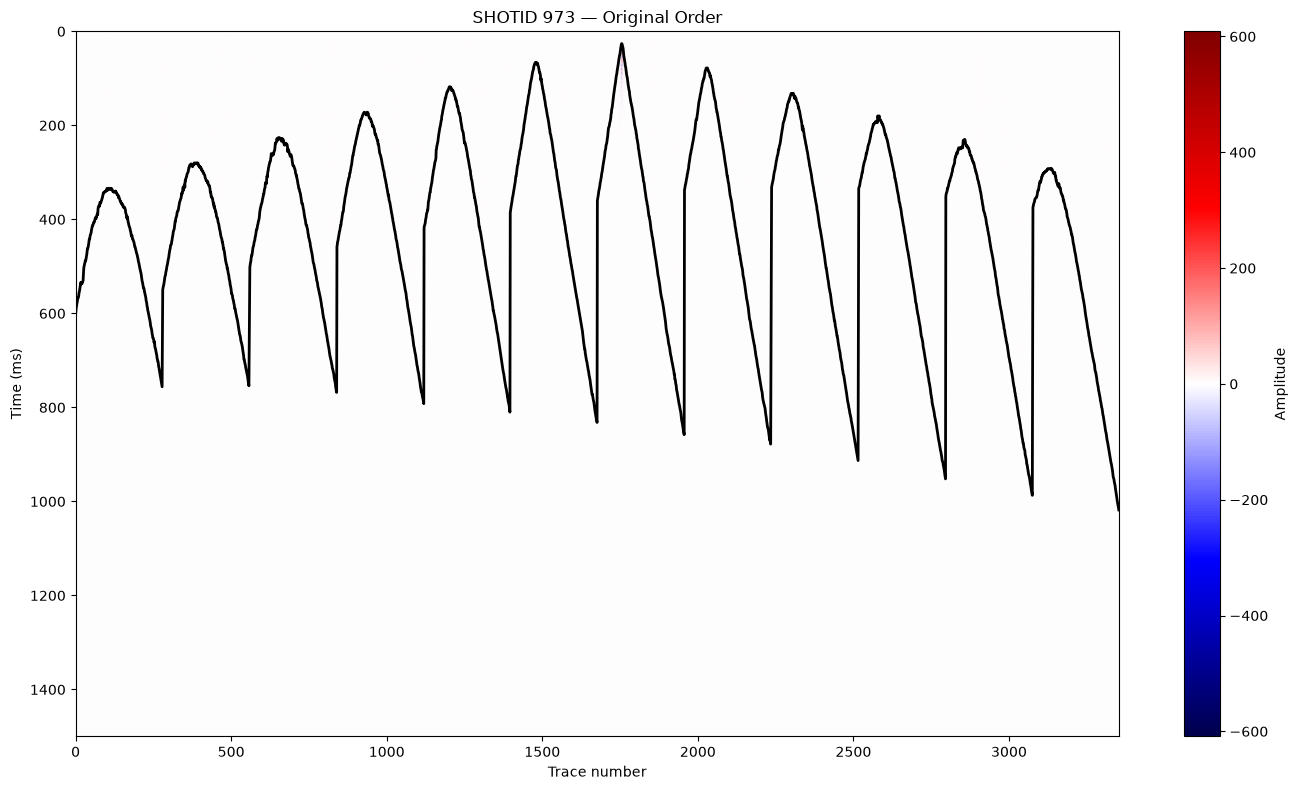

In [370]:
shot = get_shot(
    path,
    shot_id,
    order_by=None
)

plot_shot(
    shot,
    f"SHOTID {shot_id} — Original Order",
    x_axis="trace"
)

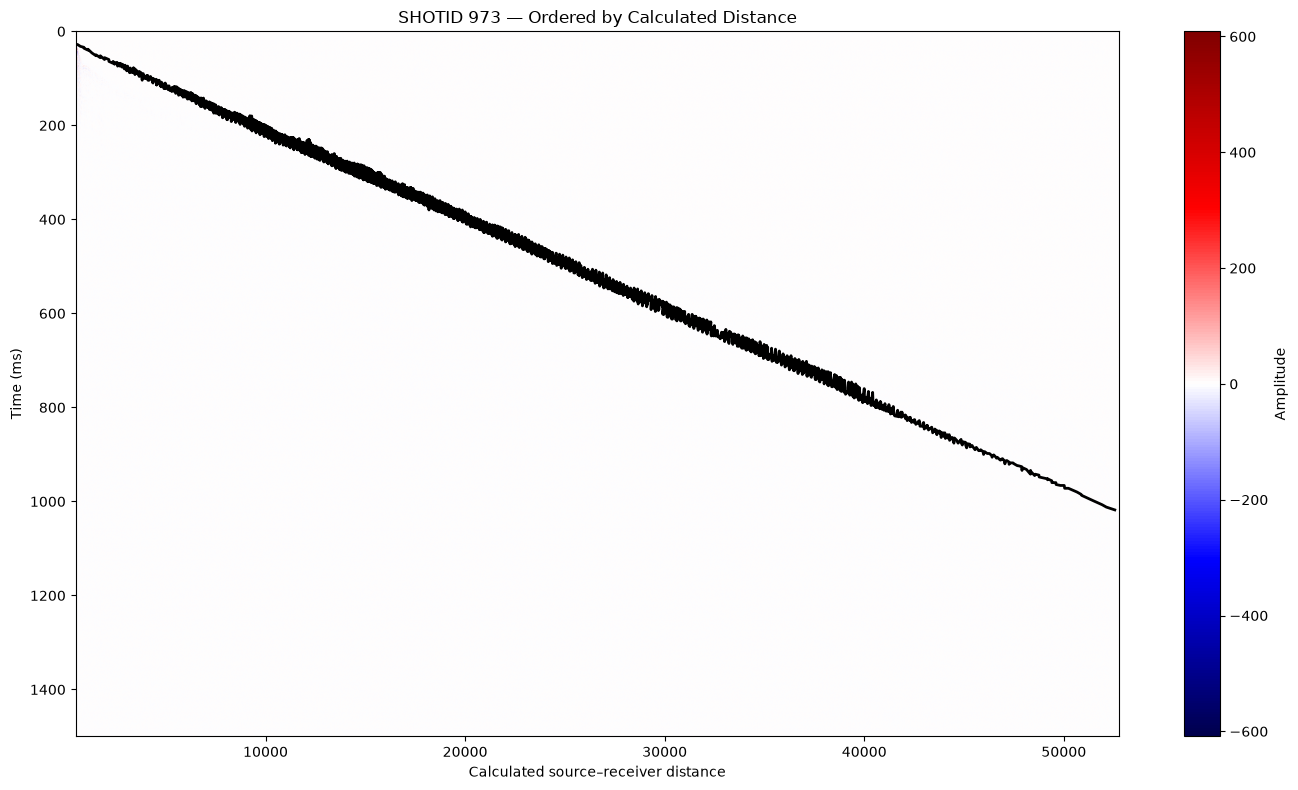

In [371]:
shot = get_shot(
    path,
    shot_id,
    order_by="distance"
)

plot_shot(
    shot,
    f"SHOTID {shot_id} — Ordered by Calculated Distance",
    x_axis="distance"
)

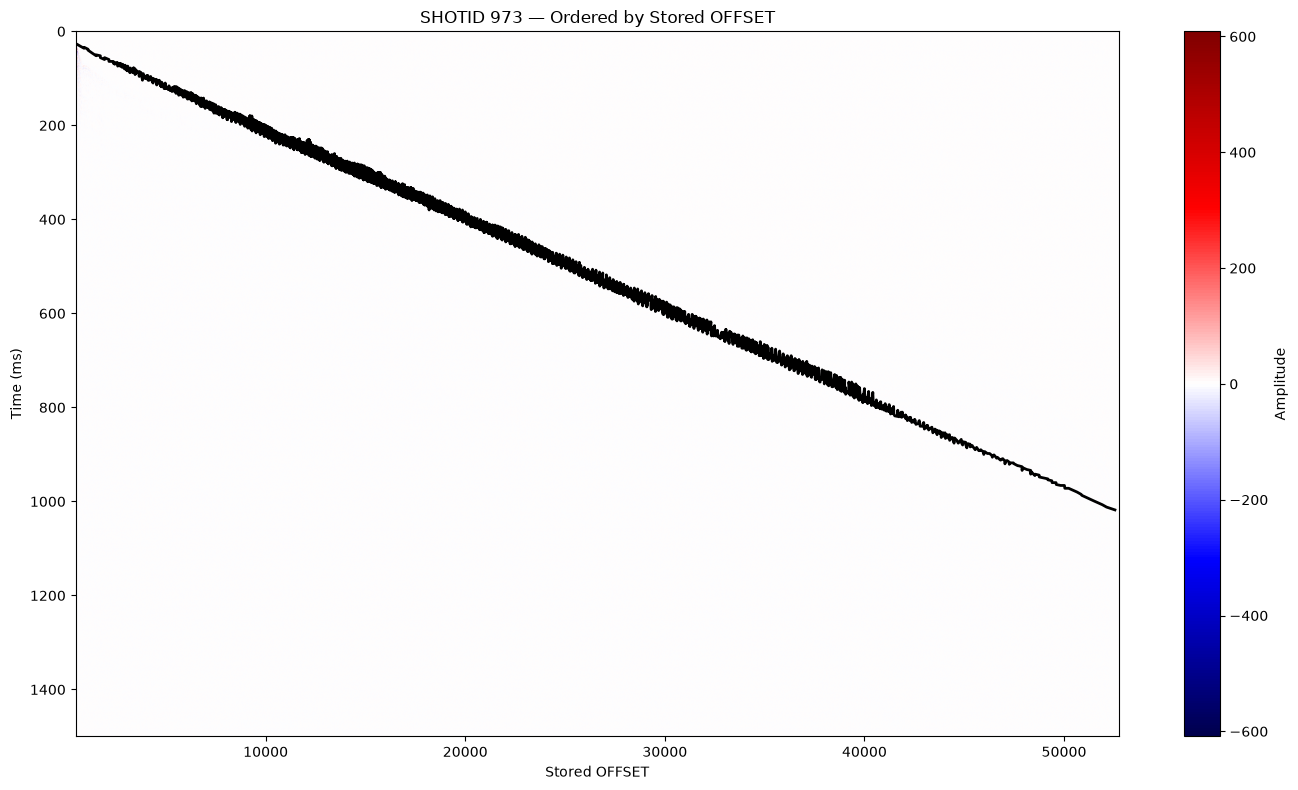

In [372]:
shot = get_shot(
    path,
    shot_id,
    order_by="offset"
)

plot_shot(
    shot,
    f"SHOTID {shot_id} — Ordered by Stored OFFSET",
    x_axis="offset"
)

## Halfmile

In [373]:
path = r"data\Halfmile3D_add_geom_sorted.hdf5"

inspect_dataset(path)

DATASET
Traces             : 1,099,559
Samples per trace  : 751
Data type          : float32
Unique SHOTIDs     : 690
Traces per shot    : 1575 - 1604
Average per shot   : 1593.6
Median per shot    : 1604.0
Labeled traces     : 993,189
Unlabeled traces   : 106,370
Labeled percentage : 90.33%
SAMP_RATE values   : [2000]
First-break range : 11.0 - 1482.0 ms

First 10 SHOTIDs:
  20021449: 1578 traces
  20021451: 1578 traces
  20021453: 1578 traces
  20021455: 1578 traces
  20021457: 1575 traces
  20021459: 1578 traces
  20021461: 1578 traces
  20021462: 1578 traces
  20021463: 1578 traces
  20021464: 1578 traces

Metadata:
  INLINE          shape=(1099559, 1), dtype=uint32
  CROSSLINE       shape=(1099559, 1), dtype=uint32
  CDP             shape=(1099559, 1), dtype=uint32
  OFFSET          shape=(1099559, 1), dtype=int32
  SOURCE_X        shape=(1099559, 1), dtype=int32
  SOURCE_Y        shape=(1099559, 1), dtype=int32
  REC_X           shape=(1099559, 1), dtype=int32
  REC_Y           s

(array([20021449, 20021451, 20021453, 20021455, 20021457, 20021459,
        20021461, 20021462, 20021463, 20021464, 20021470, 20021472,
        20021474, 20021476, 20021484, 20021487, 20021490, 20021493,
        20021498, 20021501, 20021504, 20021507, 20021510, 20021513,
        20021516, 20021519, 20021521, 20021524, 20021527, 20021530,
        20021533, 20021538, 20021542, 20021547, 20021550, 20021553,
        20021556, 20021558, 20021561, 20021564, 20021567, 20021570,
        20021573, 20021580, 20041588, 20041590, 20041593, 20041596,
        20041599, 20041605, 20041608, 20041611, 20041613, 20041616,
        20041625, 20041627, 20041629, 20041631, 20041633, 20041635,
        20041637, 20041639, 20041646, 20041648, 20041650, 20041652,
        20041654, 20041656, 20041658, 20041660, 20041663, 20041665,
        20041675, 20041677, 20041679, 20041682, 20041684, 20041686,
        20041689, 20041690, 20061617, 20061618, 20061619, 20061620,
        20061621, 20061622, 20061623, 20061624, 

TRACE 5
SHOTID       : 20021449
INLINE       : 1109
CROSSLINE    : 1228
CDP          : 11091228
OFFSET       : 636
CALC DISTANCE: 636.65
DIFFERENCE   : 0.65
SOURCE       : (704570, 5243576)
RECEIVER     : (704236, 5244118)
FIRST BREAK  : 146 ms
SAMP_RATE    : 2000


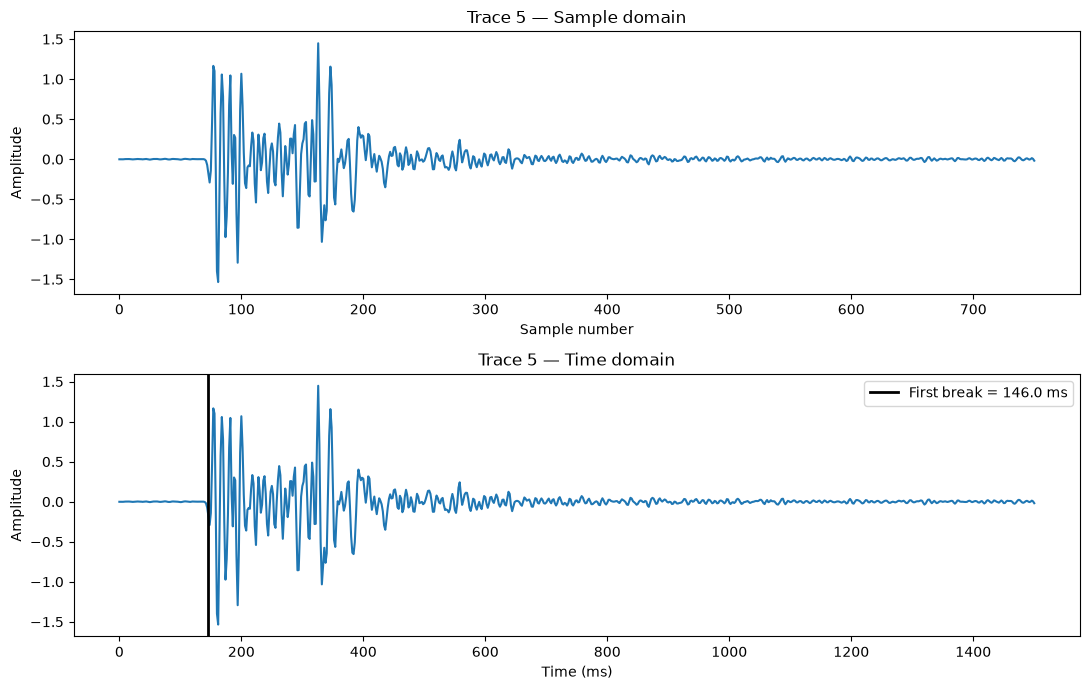

Trace 5: 751 samples, dt = 2.0 ms, first break = 146 ms


In [374]:
inspect_one_trace(path, 5)
plot_one_trace(path, 5)

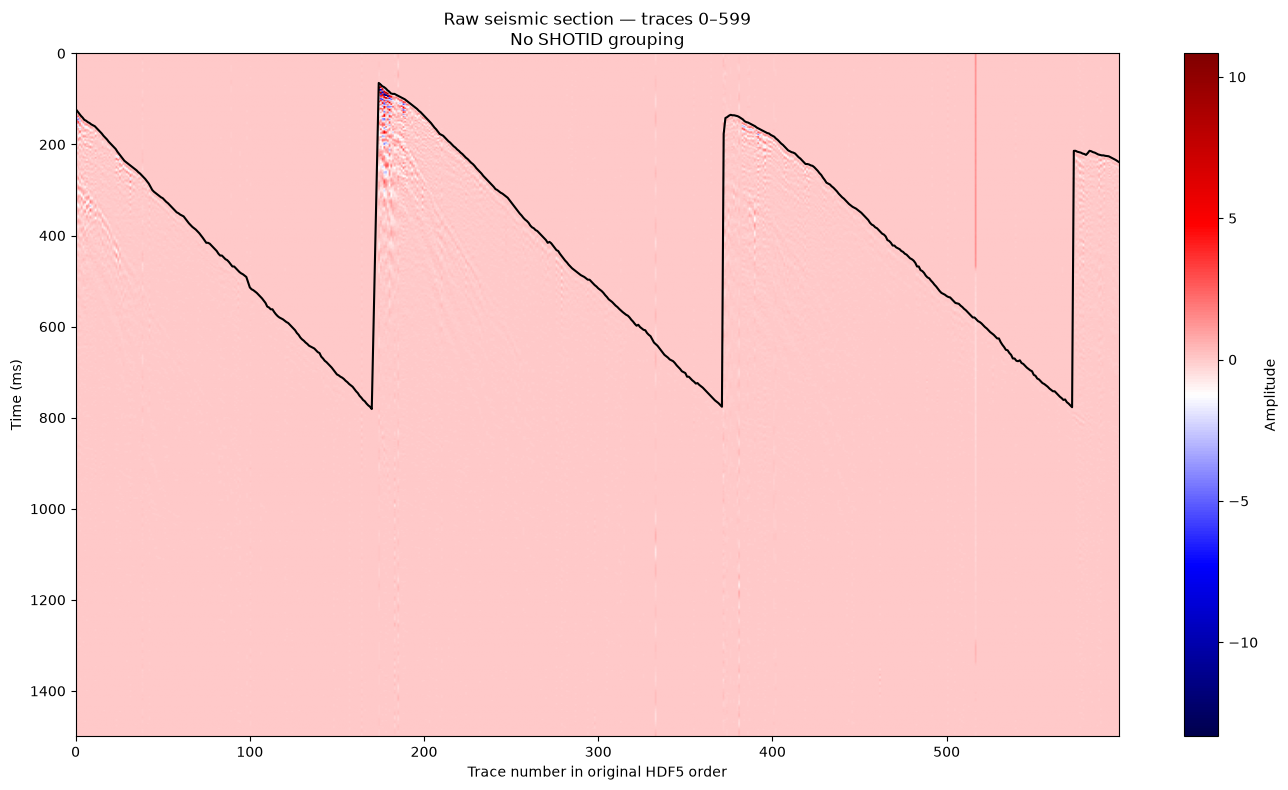

In [375]:
plot_raw_section(
    path,
    start=0,
    num_traces=600
)

In [376]:
raw = load_metadata(path)

compare_distance_offset(raw)

CALCULATED DISTANCE vs STORED OFFSET
Mean difference    : 0.387
Median difference  : 0.335
Maximum difference : 1.503
90th percentile    : 0.804

Examples:
Trace 0: distance=539.94, OFFSET=540.00, diff=0.06
Trace 1: distance=559.03, OFFSET=559.00, diff=0.03
Trace 2: distance=577.65, OFFSET=578.00, diff=0.35
Trace 3: distance=598.19, OFFSET=598.00, diff=0.19
Trace 4: distance=617.40, OFFSET=617.00, diff=0.40
Trace 5: distance=636.65, OFFSET=636.00, diff=0.65
Trace 6: distance=655.93, OFFSET=656.00, diff=0.07
Trace 7: distance=675.24, OFFSET=675.00, diff=0.24
Trace 8: distance=695.41, OFFSET=695.00, diff=0.41
Trace 9: distance=714.77, OFFSET=715.00, diff=0.23


In [377]:
test_shots = select_test_shots(path, n=3)
shot_id = test_shots[0]

Selected shots:
  SHOTID 20161357: 1604 traces
  SHOTID 20161358: 1604 traces
  SHOTID 20161359: 1604 traces


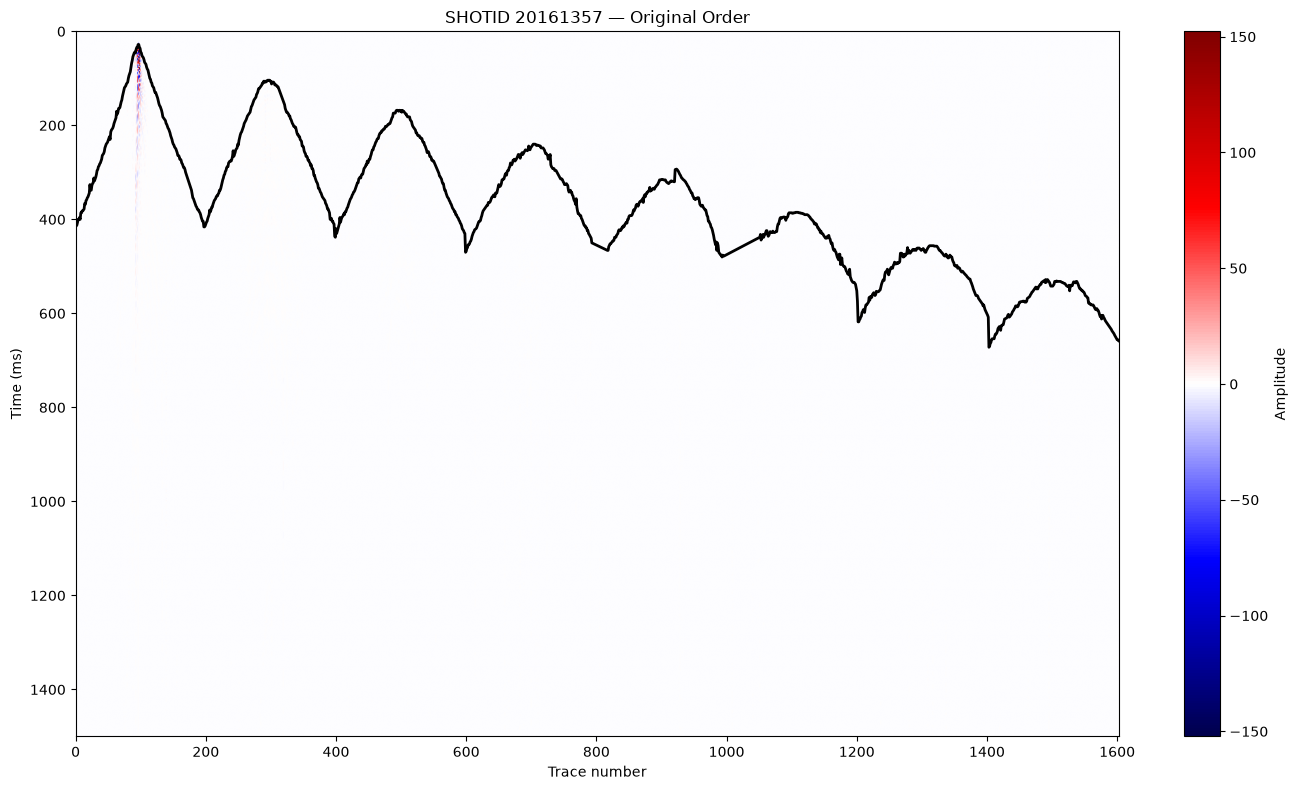

In [378]:
shot = get_shot(path, shot_id, order_by=None)

plot_shot(
    shot,
    f"SHOTID {shot_id} — Original Order",
    x_axis="trace"
)

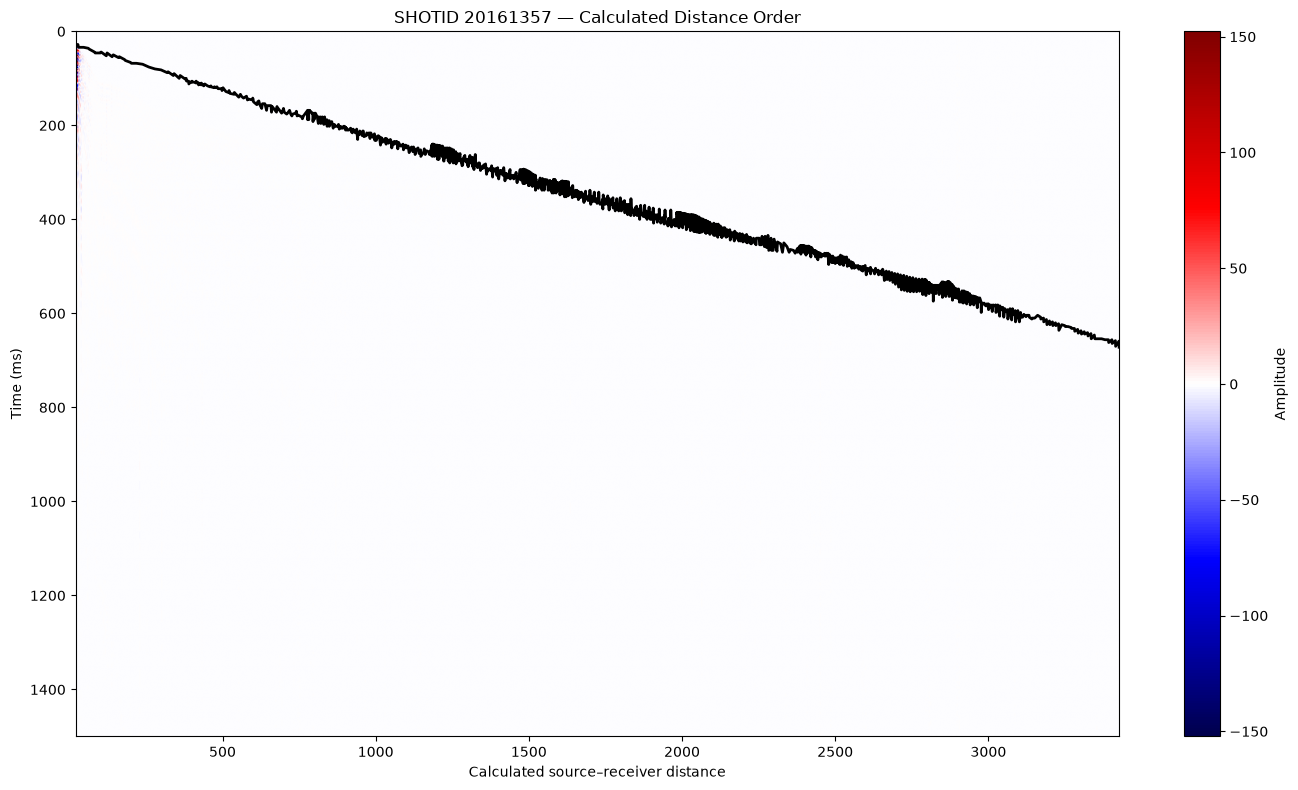

In [379]:
shot = get_shot(path, shot_id, order_by="distance")

plot_shot(
    shot,
    f"SHOTID {shot_id} — Calculated Distance Order",
    x_axis="distance"
)

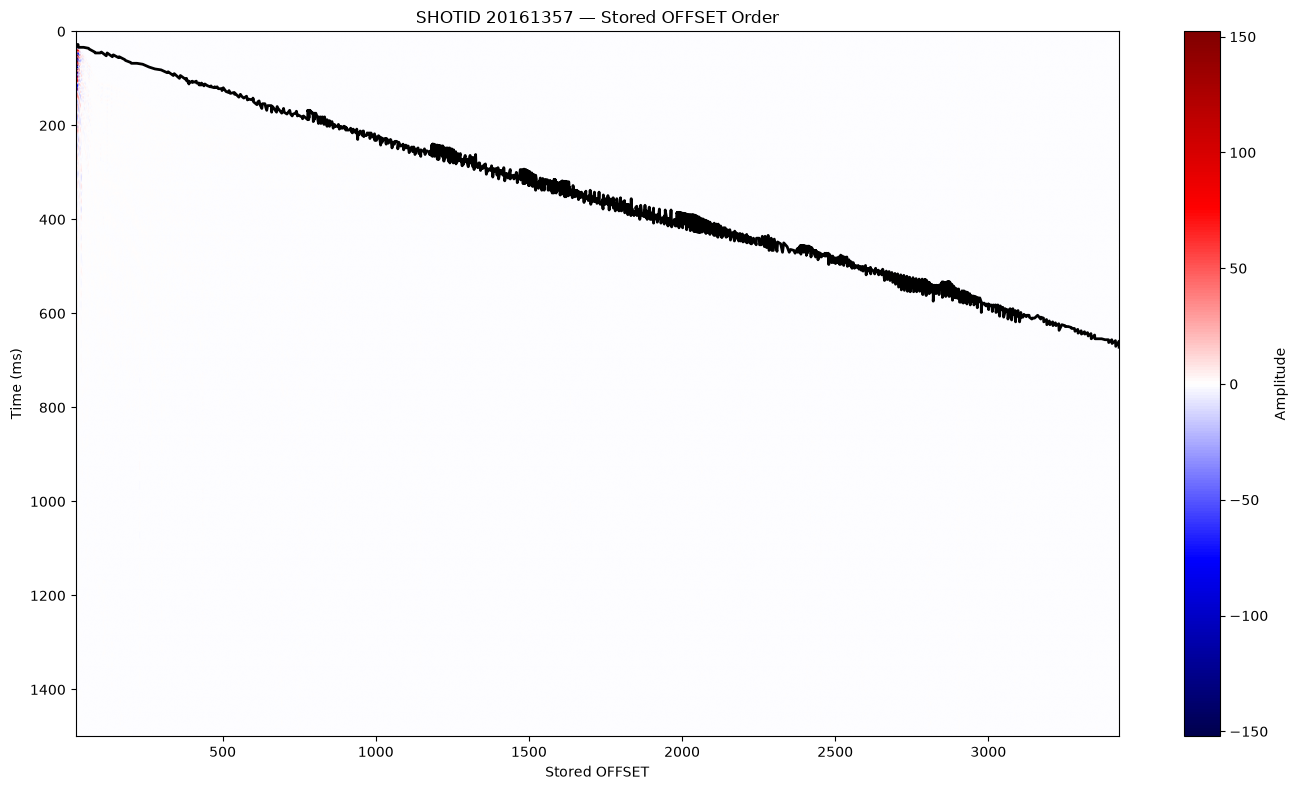

In [380]:
shot = get_shot(path, shot_id, order_by="offset")

plot_shot(
    shot,
    f"SHOTID {shot_id} — Stored OFFSET Order",
    x_axis="offset"
)

## Lalor

In [381]:
path = r"data\Lalor_raw_z_1500ms_norp_geom_v3.hdf5"

inspect_dataset(path)


DATASET
Traces             : 2,424,923
Samples per trace  : 1,501
Data type          : float32
Unique SHOTIDs     : 907
Traces per shot    : 1 - 2685
Average per shot   : 2673.6
Median per shot    : 2685.0
Labeled traces     : 1,211,857
Unlabeled traces   : 1,213,066
Labeled percentage : 49.98%
SAMP_RATE values   : [1000]
First-break range : 2.0 - 881.0 ms

First 10 SHOTIDs:
  24: 2685 traces
  25: 2685 traces
  26: 2685 traces
  27: 2685 traces
  28: 2685 traces
  29: 2685 traces
  30: 2685 traces
  31: 2685 traces
  32: 2685 traces
  33: 2685 traces

Metadata:
  INLINE          shape=(2424923, 1), dtype=uint32
  CROSSLINE       shape=(2424923, 1), dtype=uint32
  CDP             shape=(2424923, 1), dtype=uint32
  OFFSET          shape=(2424923, 1), dtype=int32
  SOURCE_X        shape=(2424923, 1), dtype=int32
  SOURCE_Y        shape=(2424923, 1), dtype=int32
  REC_X           shape=(2424923, 1), dtype=int32
  REC_Y           shape=(2424923, 1), dtype=int32
  SHOTID          shape=(242

(array([ 24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,
         37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,
         50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,
         63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,
         76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
         89,  90,  91,  92,  93,  94,  95,  96,  97,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        144, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157,
        158, 159, 160, 161, 162, 163, 165, 166, 167, 168, 169, 170, 171,
        172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184,
        185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197,
        198, 199, 200, 201, 202, 203, 204, 205, 206

TRACE 5
SHOTID       : 24
INLINE       : 1001
CROSSLINE    : 1054
CDP          : 10011054
OFFSET       : 9678
CALC DISTANCE: 9678.31
DIFFERENCE   : 0.31
SOURCE       : (22376, 137388)
RECEIVER     : (29387, 144060)
FIRST BREAK  : 170 ms
SAMP_RATE    : 1000


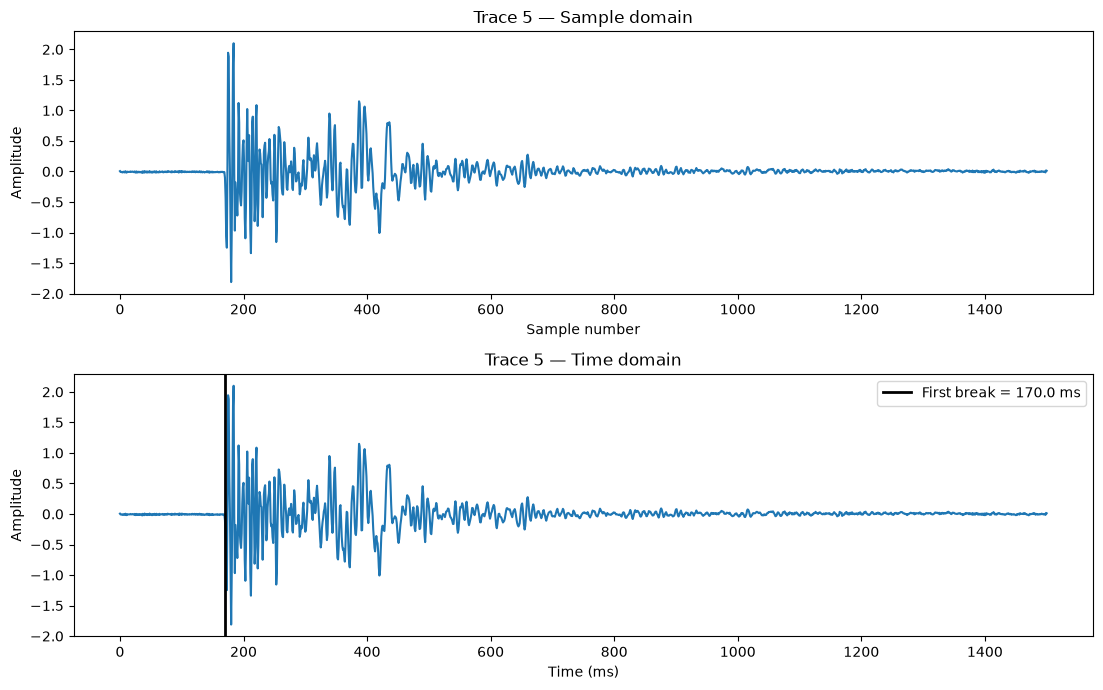

Trace 5: 1501 samples, dt = 1.0 ms, first break = 170 ms


In [382]:
inspect_one_trace(path, 5)
plot_one_trace(path, 5, 1501)

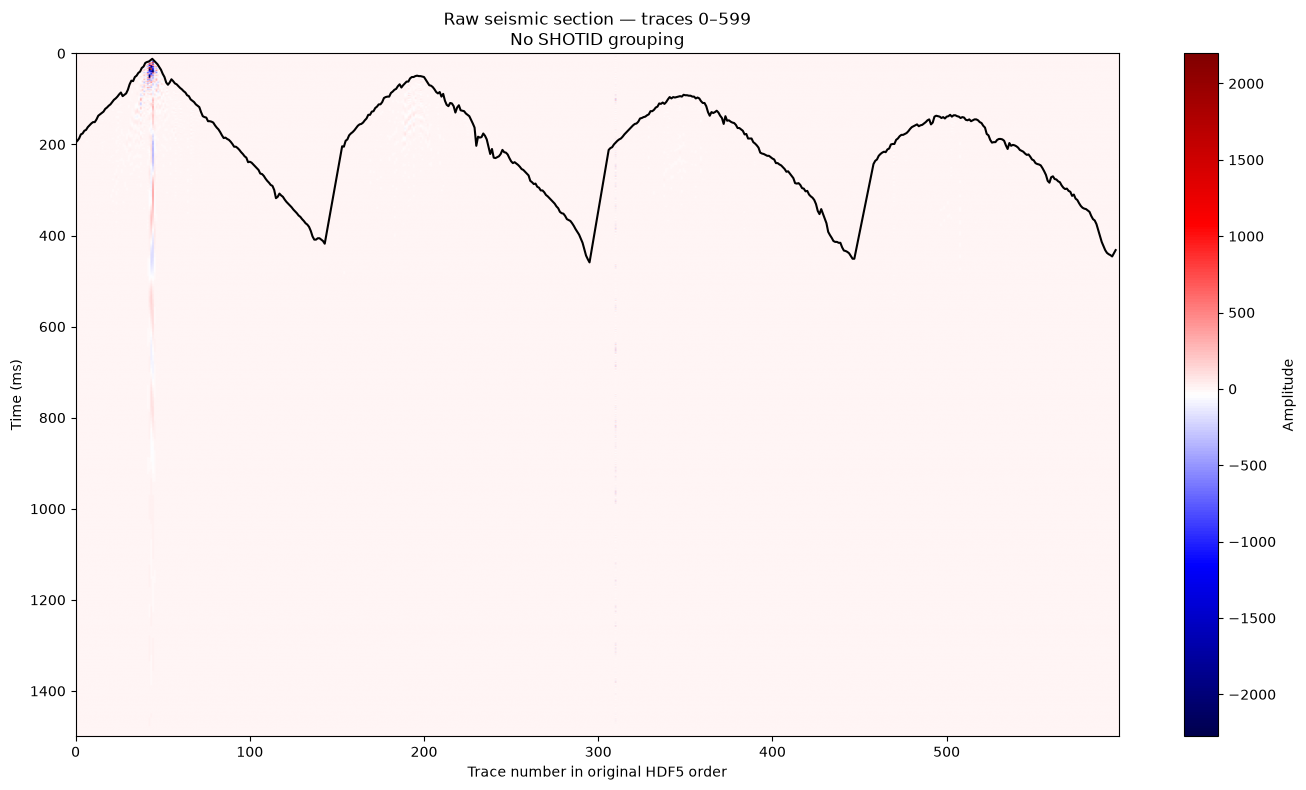

In [383]:
plot_raw_section(
    path,
    start=0,
    num_traces=600
)

In [384]:
raw = load_metadata(path)
compare_distance_offset(raw)

CALCULATED DISTANCE vs STORED OFFSET
Mean difference    : 0.249
Median difference  : 0.248
Maximum difference : 0.510
90th percentile    : 0.450

Examples:
Trace 0: distance=10936.33, OFFSET=10936.00, diff=0.33
Trace 1: distance=10692.75, OFFSET=10693.00, diff=0.25
Trace 2: distance=10446.31, OFFSET=10446.00, diff=0.31
Trace 3: distance=10185.12, OFFSET=10185.00, diff=0.12
Trace 4: distance=9933.88, OFFSET=9934.00, diff=0.12
Trace 5: distance=9678.31, OFFSET=9678.00, diff=0.31
Trace 6: distance=9430.86, OFFSET=9431.00, diff=0.14
Trace 7: distance=9189.41, OFFSET=9189.00, diff=0.41
Trace 8: distance=8936.73, OFFSET=8937.00, diff=0.27
Trace 9: distance=8686.57, OFFSET=8687.00, diff=0.43


In [385]:
test_shots = select_test_shots(path, n=3)
shot_id = test_shots[0]

Selected shots:
  SHOTID 24: 2685 traces
  SHOTID 958: 2685 traces
  SHOTID 957: 2685 traces


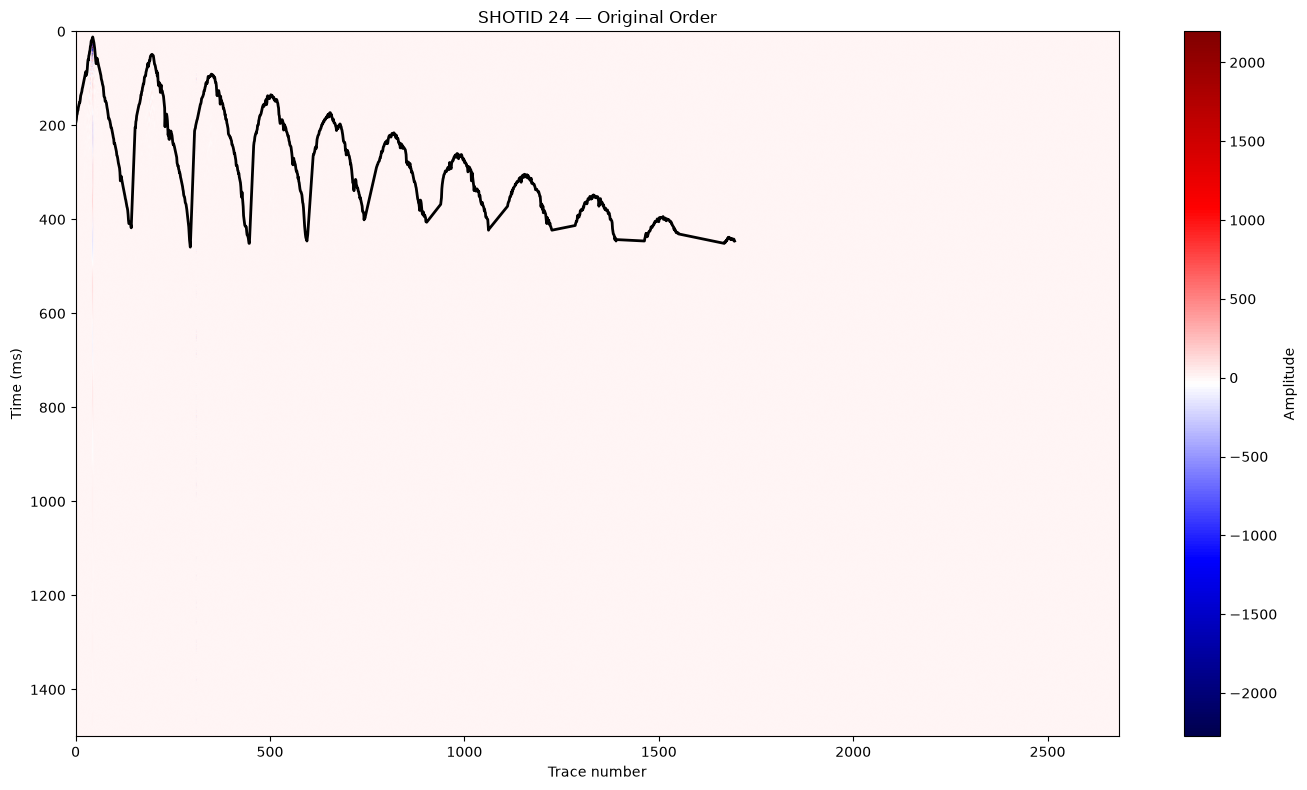

In [386]:
shot = get_shot(path, shot_id, order_by=None)

plot_shot(
    shot,
    f"SHOTID {shot_id} — Original Order",
    x_axis="trace"
)


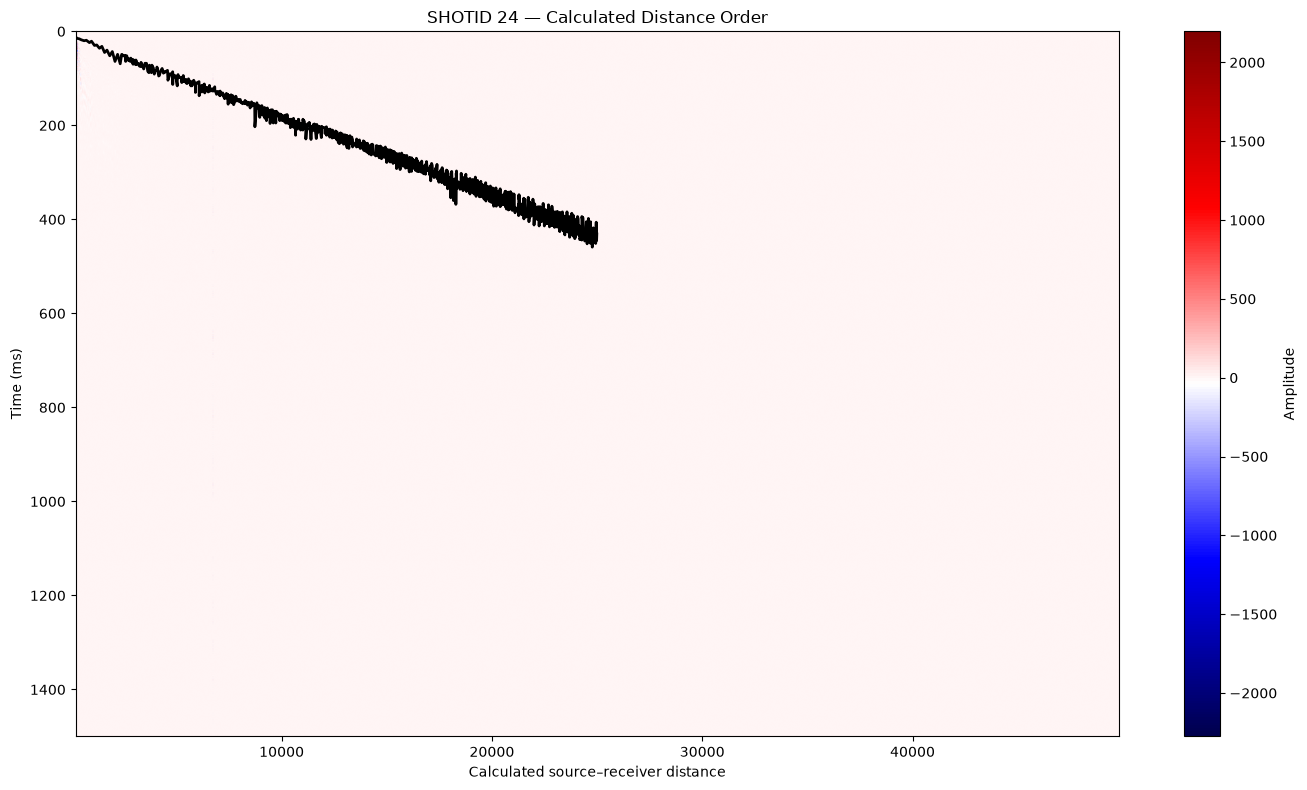

In [387]:
shot = get_shot(path, shot_id, order_by="distance")

plot_shot(
    shot,
    f"SHOTID {shot_id} — Calculated Distance Order",
    x_axis="distance"
)

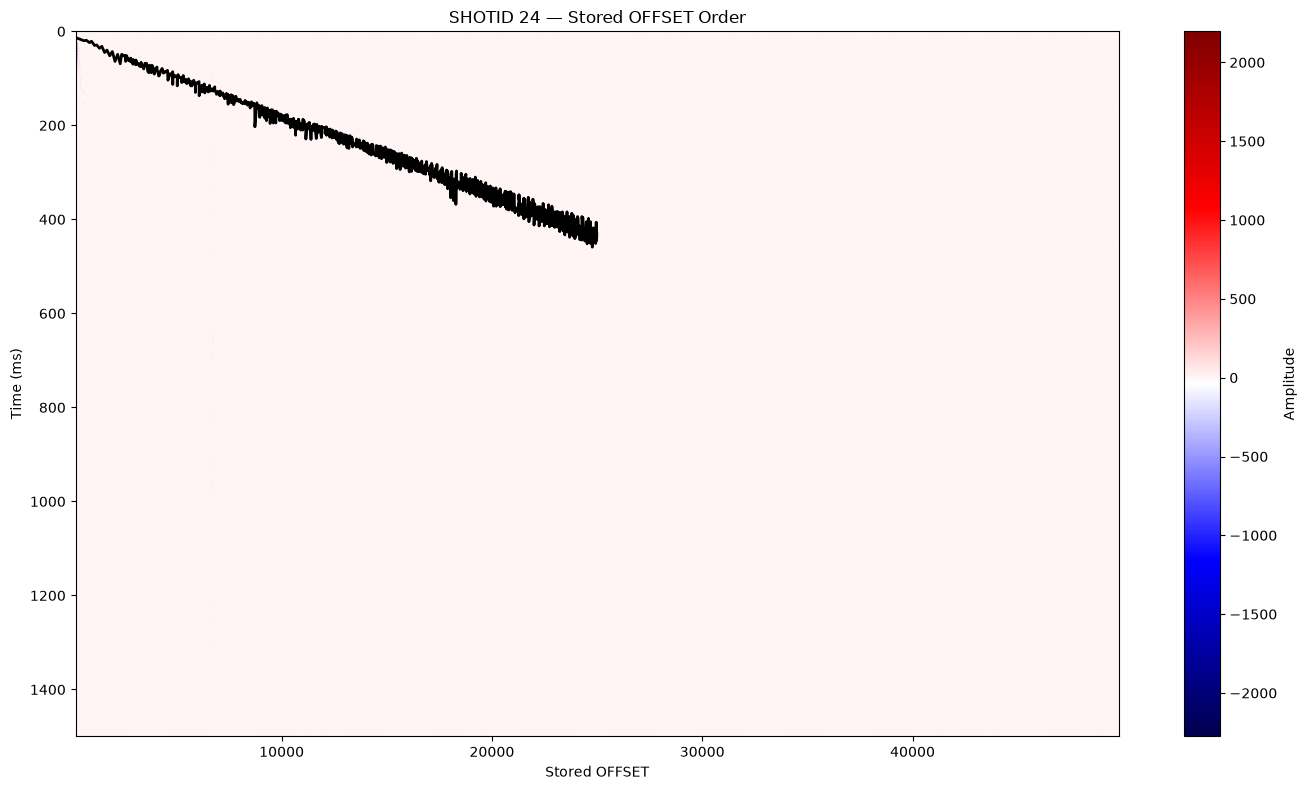

In [388]:
shot = get_shot(path, shot_id, order_by="offset")

plot_shot(
    shot,
    f"SHOTID {shot_id} — Stored OFFSET Order",
    x_axis="offset"
)

## Sudburry

In [389]:
path = r"data\preprocessed_Sudbury3D.hdf"

inspect_dataset(path)

DATASET
Traces             : 1,810,220
Samples per trace  : 1,001
Data type          : float32
Unique SHOTIDs     : 1,016
Traces per shot    : 670 - 1983
Average per shot   : 1781.7
Median per shot    : 1763.0
Labeled traces     : 200,338
Unlabeled traces   : 1,609,882
Labeled percentage : 11.07%
SAMP_RATE values   : [2000]
First-break range : 10.0 - 599.0 ms

First 10 SHOTIDs:
  2: 1138 traces
  3: 1138 traces
  4: 1138 traces
  6: 1138 traces
  7: 1138 traces
  8: 1138 traces
  9: 1138 traces
  10: 1138 traces
  11: 1138 traces
  12: 1138 traces

Metadata:
  INLINE          shape=(1810220, 1), dtype=uint32
  CROSSLINE       shape=(1810220, 1), dtype=uint32
  CDP             shape=(1810220, 1), dtype=uint32
  OFFSET          shape=(1810220, 1), dtype=int32
  SOURCE_X        shape=(1810220, 1), dtype=int32
  SOURCE_Y        shape=(1810220, 1), dtype=int32
  REC_X           shape=(1810220, 1), dtype=int32
  REC_Y           shape=(1810220, 1), dtype=int32
  SHOTID          shape=(1810220

(array([   2,    3,    4, ..., 1783, 1784, 1785],
       shape=(1016,), dtype=uint32),
 array([1138, 1138, 1138, ..., 1763, 1763, 1763], shape=(1016,)))

TRACE 5
SHOTID       : 2
INLINE       : 0
CROSSLINE    : 0
CDP          : 106715
OFFSET       : 3473
CALC DISTANCE: 347364.51
DIFFERENCE   : 343891.51
SOURCE       : (46087859, 515144450)
RECEIVER     : (46010759, 514805750)
FIRST BREAK  : 0 ms
SAMP_RATE    : 2000


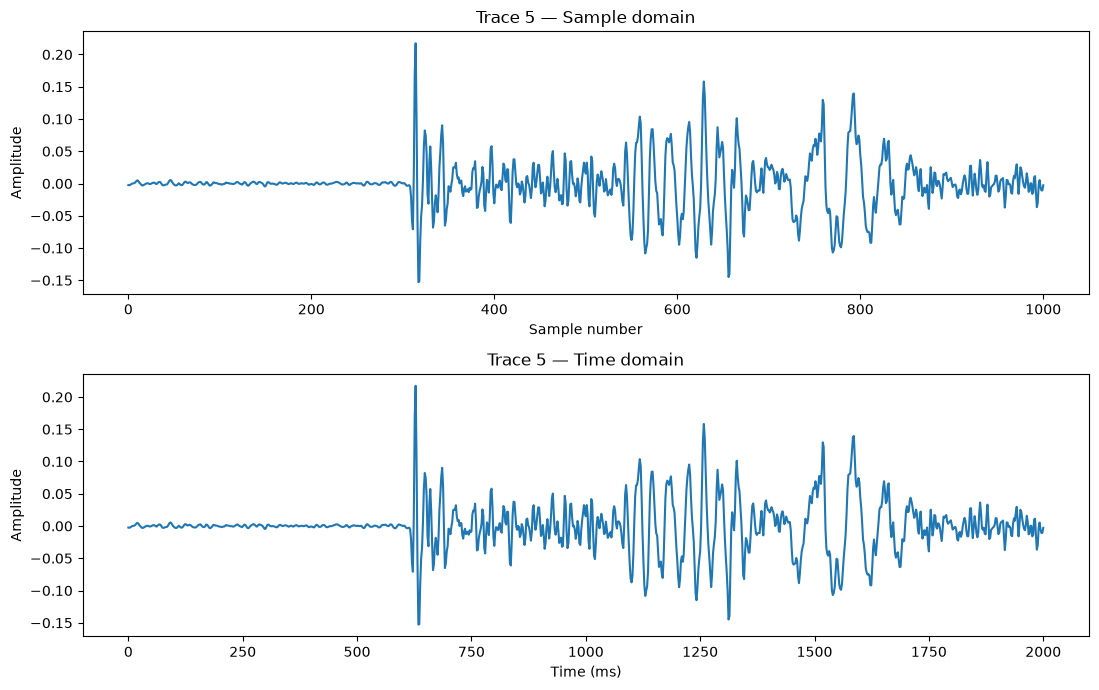

Trace 5: 1001 samples, dt = 2.0 ms, first break = 0 ms


In [390]:
inspect_one_trace(path, 5)
plot_one_trace(path, 5, 1001)

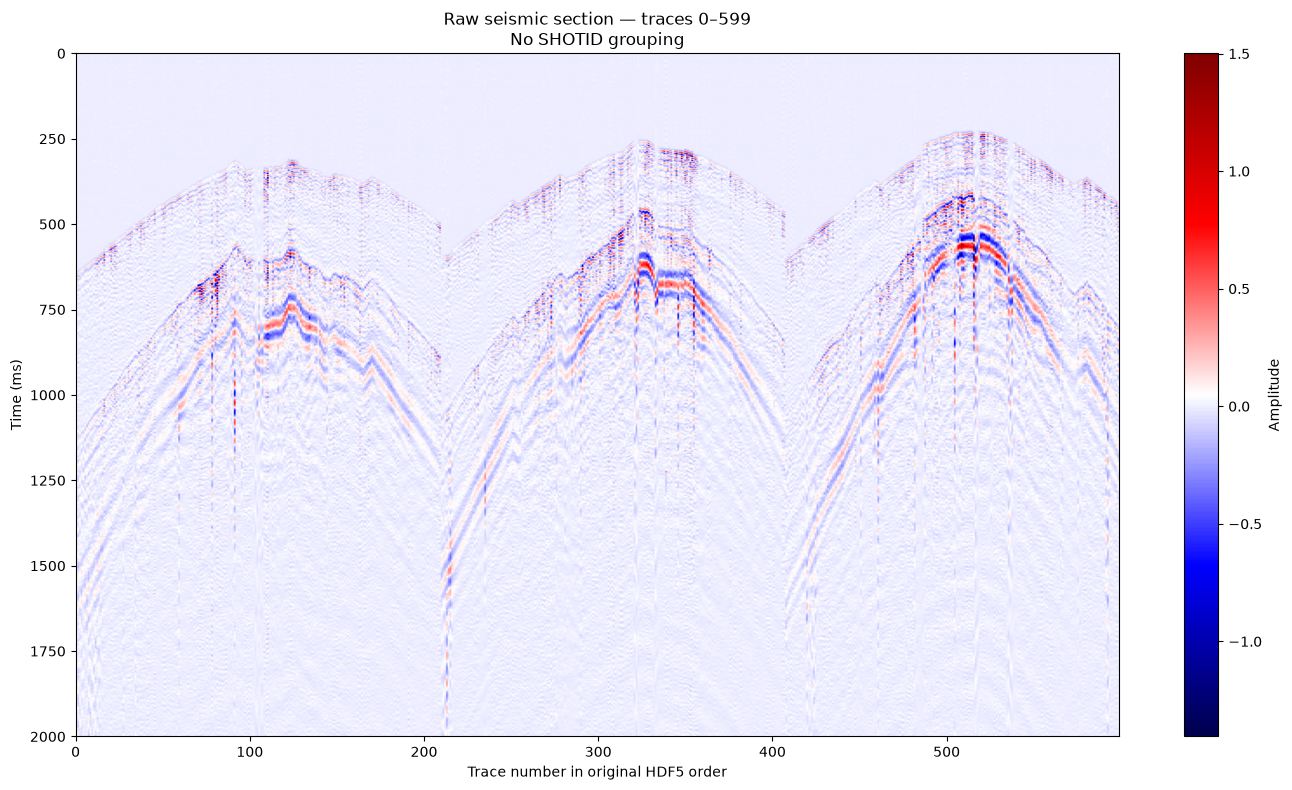

In [391]:
plot_raw_section(
    path,
    start=0,
    num_traces=600
)

In [392]:
raw = load_metadata(path)
compare_distance_offset(raw)

CALCULATED DISTANCE vs STORED OFFSET
Mean difference    : 239333.339
Median difference  : 228824.168
Maximum difference : 708412.695
90th percentile    : 405630.080

Examples:
Trace 0: distance=360349.49, OFFSET=3603.00, diff=356746.49
Trace 1: distance=357723.49, OFFSET=3577.00, diff=354146.49
Trace 2: distance=355098.72, OFFSET=3551.00, diff=351547.72
Trace 3: distance=352480.41, OFFSET=3525.00, diff=348955.41
Trace 4: distance=349917.16, OFFSET=3499.00, diff=346418.16
Trace 5: distance=347364.51, OFFSET=3473.00, diff=343891.51
Trace 6: distance=344822.58, OFFSET=3448.00, diff=341374.58
Trace 7: distance=342230.47, OFFSET=3422.00, diff=338808.47
Trace 8: distance=339697.98, OFFSET=3396.00, diff=336301.98
Trace 9: distance=337119.90, OFFSET=3371.00, diff=333748.90


In [393]:
test_shots = select_test_shots(path, n=3)
shot_id = test_shots[0]

Selected shots:
  SHOTID 177: 1983 traces
  SHOTID 178: 1983 traces
  SHOTID 179: 1983 traces


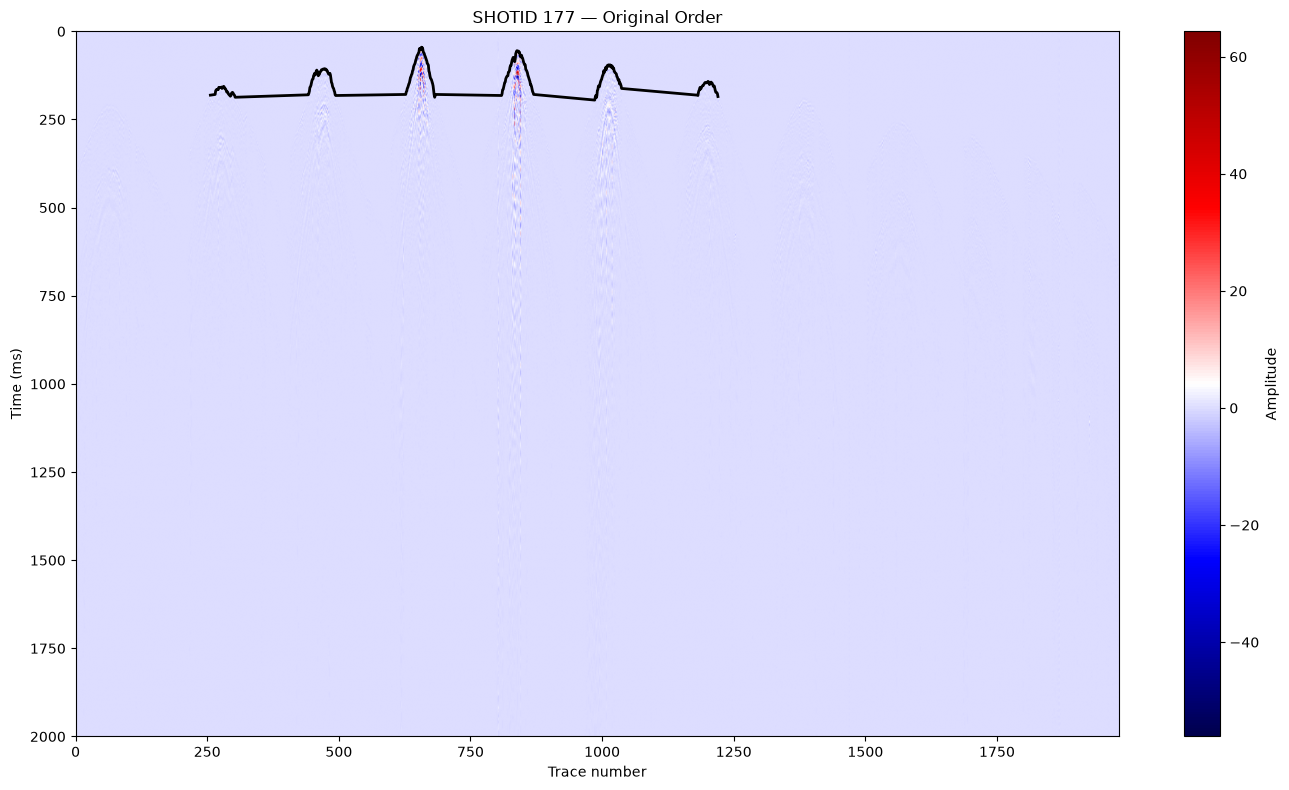

In [394]:
shot = get_shot(path, shot_id, order_by=None)

plot_shot(
    shot,
    f"SHOTID {shot_id} — Original Order",
    x_axis="trace"
)


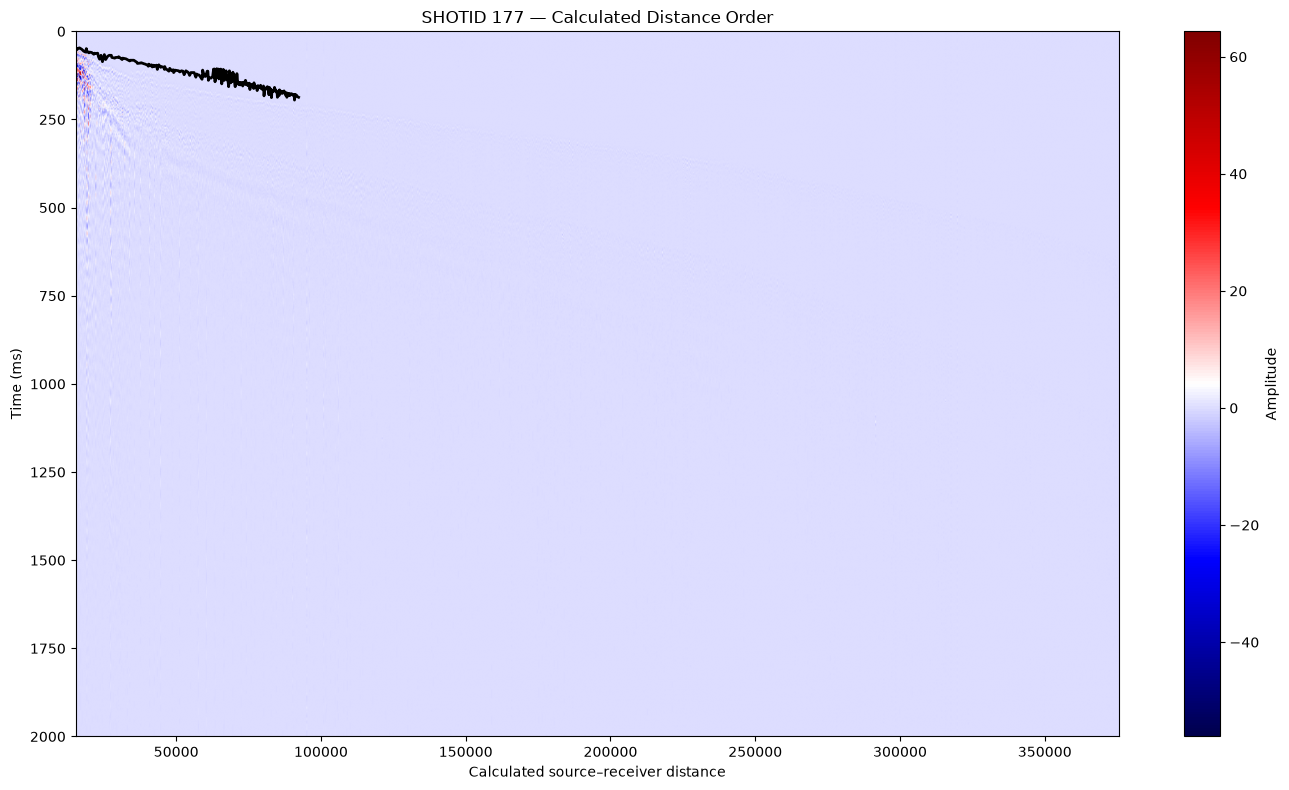

In [395]:
shot = get_shot(path, shot_id, order_by="distance")

plot_shot(
    shot,
    f"SHOTID {shot_id} — Calculated Distance Order",
    x_axis="distance"
)

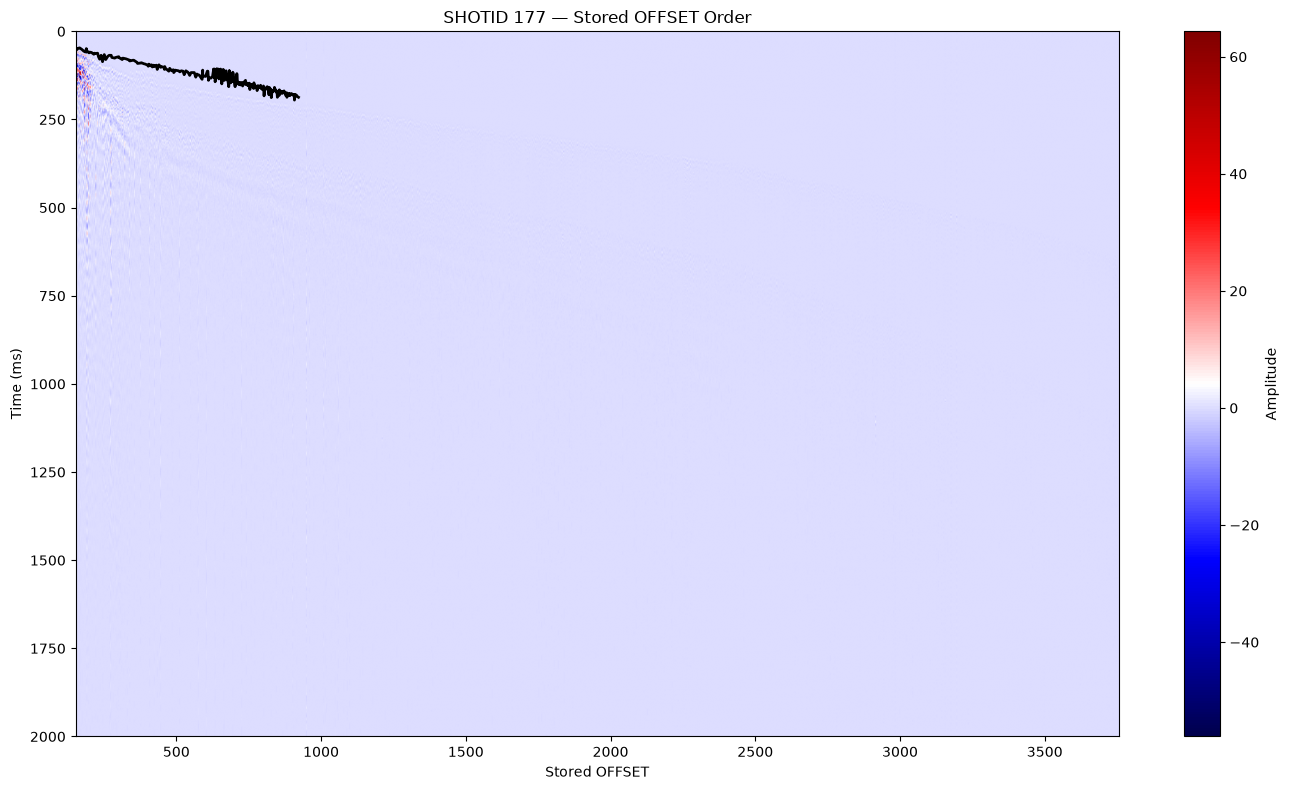

In [396]:
shot = get_shot(path, shot_id, order_by="offset")

plot_shot(
    shot,
    f"SHOTID {shot_id} — Stored OFFSET Order",
    x_axis="offset"
)

In [350]:
def check_coordinate_scale(path):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        coord_scale = g["COORD_SCALE"][:].ravel()

        print("COORD_SCALE values:")
        print(np.unique(coord_scale))
check_coordinate_scale(r"data\\Lalor_raw_z_1500ms_norp_geom_v3.hdf5")

COORD_SCALE values:
[-10]


In [397]:
def inspect_coord_scale(path):
    with h5py.File(path, "r") as f:
        g = f[GROUP]

        coord_scale = g["COORD_SCALE"][:].ravel()
        offset = g["OFFSET"][:].ravel().astype(float)

        source_x = g["SOURCE_X"][:].ravel().astype(float)
        source_y = g["SOURCE_Y"][:].ravel().astype(float)
        rec_x = g["REC_X"][:].ravel().astype(float)
        rec_y = g["REC_Y"][:].ravel().astype(float)

    # Raw distance
    raw_distance = np.sqrt(
        (rec_x - source_x)**2 +
        (rec_y - source_y)**2
    )

    # Apply SEG-Y-style coordinate scale
    scale = np.where(
        coord_scale > 0,
        coord_scale,
        np.where(
            coord_scale < 0,
            1 / np.abs(coord_scale),
            1.0
        )
    )

    scaled_source_x = source_x * scale
    scaled_source_y = source_y * scale
    scaled_rec_x = rec_x * scale
    scaled_rec_y = rec_y * scale

    scaled_distance = np.sqrt(
        (scaled_rec_x - scaled_source_x)**2 +
        (scaled_rec_y - scaled_source_y)**2
    )

    print("=" * 70)
    print(path)
    print("=" * 70)

    print("COORD_SCALE unique values:")
    print(np.unique(coord_scale))

    print("\nOFFSET:")
    print("min:", offset.min())
    print("max:", offset.max())

    print("\nRAW distance:")
    print("min:", raw_distance.min())
    print("max:", raw_distance.max())

    print("\nSCALED distance:")
    print("min:", scaled_distance.min())
    print("max:", scaled_distance.max())

    print("\nDifference RAW distance vs OFFSET:")
    raw_diff = np.abs(raw_distance - offset)
    print("median:", np.median(raw_diff))
    print("mean  :", np.mean(raw_diff))
    print("max   :", np.max(raw_diff))

    print("\nDifference SCALED distance vs OFFSET:")
    scaled_diff = np.abs(scaled_distance - offset)
    print("median:", np.median(scaled_diff))
    print("mean  :", np.mean(scaled_diff))
    print("max   :", np.max(scaled_diff))

In [398]:
inspect_coord_scale(r"data\\Brunswick_orig_1500ms_V2.hdf5")
inspect_coord_scale(r"data\\Halfmile3D_add_geom_sorted.hdf5")
inspect_coord_scale(r"data\\Lalor_raw_z_1500ms_norp_geom_v3.hdf5")
inspect_coord_scale(r"data\\preprocessed_Sudbury3D.hdf")

data\\Brunswick_orig_1500ms_V2.hdf5
COORD_SCALE unique values:
[-10]

OFFSET:
min: 20.0
max: 71890.0

RAW distance:
min: 20.0
max: 71882.24050487019

SCALED distance:
min: 2.0
max: 7188.224050487019

Difference RAW distance vs OFFSET:
median: 3.505689864402484
mean  : 4.063488770445429
max   : 18.77482767813126

Difference SCALED distance vs OFFSET:
median: 19107.16804716004
mean  : 21324.13539847561
max   : 64701.77594951298
data\\Halfmile3D_add_geom_sorted.hdf5
COORD_SCALE unique values:
[1]

OFFSET:
min: 0.0
max: 4866.0

RAW distance:
min: 0.0
max: 4865.900327791353

SCALED distance:
min: 0.0
max: 4865.900327791353

Difference RAW distance vs OFFSET:
median: 0.3354945129397038
mean  : 0.3870407640158795
max   : 1.5034246896671277

Difference SCALED distance vs OFFSET:
median: 0.3354945129397038
mean  : 0.3870407640158795
max   : 1.5034246896671277
data\\Lalor_raw_z_1500ms_norp_geom_v3.hdf5
COORD_SCALE unique values:
[-10]

OFFSET:
min: 1.0
max: 57827.0

RAW distance:
min: 1.0
max: 5